# MoTrPAC: six tissues on one network

The MoTrPAC consortium trained rats on a treadmill for 1, 2, 4 and 8 weeks
and profiled transcriptome, proteome and metabolome across tissues
([*Nature* 629:174-183, 2024](https://doi.org/10.1038/s41586-023-06877-w)).
It is the case where trans-omics earns its keep by comparison: **one shared
interactome, six different responses on it**.

MoTrPAC distributes a time-course ANOVA, whose F statistic has no sign, so
the direction is computed here from the normalised data: each timepoint
against its sedentary controls, as the mean of the within-sex differences,
with a Welch test on sex-centred values.

Needs the rat network: `python maintenance/build_networks.py --organisms rat
--brenda`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from transnet import (
    build_name_id_map,
    compare_transomic_networks,
    expression_concordance,
    map_modification_sites,
    map_omics_to_network,
    reaction_regulation_table,
    responsive_subnetwork,
    trace_regulatory_paths,
    transcription_factor_activity,
    transomic_hubs,
)
from transnet import (                      # noqa: E402  (grouped for readability)
    cross_layer_connectivity,
    downstream_influence,
    layer_coverage,
    metabolite_regulatory_roles,
    regulation_axis_summary,
    regulatory_role_enrichment,
    temporal_network_structure,
    assign_temporal_parameters,
)
from transnet.analysis import hub_rankings, path_verdicts, versus_chance
from transnet.datasets import (
    DATA_DIR,
    MOTRPAC_PTM_ASSAYS,
    load_motrpac_contrast,
    load_motrpac_ptm,
    motrpac_tissues,
)
from transnet.io import read_network

OUT = DATA_DIR / "motrpac_results" / "transomics"
OUT.mkdir(parents=True, exist_ok=True)
TIMEPOINT = "8w"
TISSUE_FOCUS = "SKM_GN"

source = DATA_DIR / "rat" / "latest"
network = read_network(str(source / "interactions.csv"), nodes_file=str(source / "nodes.csv"))
tissues = motrpac_tissues()
print(f"{network.number_of_nodes():,} molecules, {network.number_of_edges():,} relationships")
print("tissues:", ", ".join(tissues))

74,363 molecules, 258,015 relationships
tissues: CORTEX, HEART, KIDNEY, LIVER, LUNG, SKM_GN


In [2]:
connectivity = cross_layer_connectivity(network)
print(f"{connectivity['cross_layer_fraction']:.0%} of edges cross between layers")
connectivity["matrix"]

55% of edges cross between layers


,Transcriptome,Proteome,Reactions,Metabolome
Transcriptome,0,7849,0,0
Proteome,50903,117118,17675,0
Reactions,0,0,0,7966
Metabolome,0,0,56504,0


## Identifiers

Transcripts are Ensembl and proteins RefSeq, while the network uses Entrez
and UniProt. The maps are cached, since they are thousands of lookups.

In [3]:
def cached_map(name, features, from_type, to_type):
    path = OUT / f"idmap_{name}.json"
    if path.exists():
        return json.loads(path.read_text())
    from transnet.analysis import id_mapping
    mapped = id_mapping(pd.DataFrame({"feature": sorted(features)}), id_col="feature",
                        from_type=from_type, to_type=to_type, organism="rat")
    column = f"{to_type}_id"
    result = {k: str(v) for k, v in zip(mapped["feature"], mapped[column]) if pd.notna(v)}
    path.write_text(json.dumps(result))
    return result


contrasts = {tissue: load_motrpac_contrast(tissue, TIMEPOINT) for tissue in tissues}

transcripts = {f for t in contrasts.values() for f in t.get("Transcriptome", pd.DataFrame()).get("feature", [])}
proteins = {f for t in contrasts.values() for f in t.get("Proteome", pd.DataFrame()).get("feature", [])}
metabolites = {f for t in contrasts.values() for f in t.get("Metabolome", pd.DataFrame()).get("feature", [])}

id_map = {
    "Transcriptome": cached_map("ensembl_to_entrez", transcripts, "ensembl.gene", "entrezgene"),
    "Proteome": cached_map("refseq_to_uniprot", proteins, "refseq", "uniprot"),
    "Metabolome": build_name_id_map(network, sorted(metabolites)),
}
{layer: len(m) for layer, m in id_map.items()}

/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/pyreadr/_pyreadr_parser.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df['rownames'] = self.row_names


{'Transcriptome': 15238, 'Proteome': 10051, 'Metabolome': 274}

## Each tissue gets its own copy

The wiring is shared; the response is not.

In [4]:
graphs, mapped = {}, []
for tissue, tables in contrasts.items():
    graph = network.copy()
    report = map_omics_to_network(
        graph, tables, id_column="feature", log2fc_column="log2FC", qvalue_column="padj",
        se_column="se", id_map=id_map, qvalue_threshold=0.05,
    )
    graphs[tissue] = graph
    row = report.per_layer.assign(tissue=tissue)
    mapped.append(row[["tissue", "layer", "n_supplied", "n_matched", "n_up", "n_down"]])

pd.concat(mapped).reset_index(drop=True)

,tissue,layer,n_supplied,n_matched,n_up,n_down
0,CORTEX,Transcriptome,16442,14477,0,0
1,CORTEX,Proteome,11108,4024,10,9
2,CORTEX,Metabolome,209,90,0,0
3,HEART,Transcriptome,14442,13024,321,222
4,HEART,Proteome,9184,3164,226,146
5,HEART,Metabolome,1309,233,22,2
6,KIDNEY,Transcriptome,15981,14185,34,15
7,KIDNEY,Proteome,9852,3633,41,54
8,KIDNEY,Metabolome,1395,238,2,1
9,LIVER,Transcriptome,14435,12882,19,13


## Modification sites

MoTrPAC measures three post-translational modifications beside protein
abundance, and each answers a different question about an enzyme whose amount
did or did not change. Phosphorylation is its activity state, in every tissue
here. Acetylation and ubiquitination are heart and liver only.

The unit is a site, not a protein, so each one becomes its own Signaling node
with an edge into the protein it sits on, and several sites on one protein stay
separate because they can move opposite ways. The edge is unsigned: whether
more phosphorylation at a given site raises or lowers catalytic activity is
site-specific and not recorded, so the direction of the site and its effect on
the reaction are reported separately.

In [5]:
ptm_tables, ptm_reports = {}, []
for assay in ("PHOSPHO", "ACETYL", "UBIQ"):
    for tissue in tissues:
        if tissue not in MOTRPAC_PTM_ASSAYS[assay]:
            continue
        table = load_motrpac_ptm(tissue, assay, TIMEPOINT)
        if table.empty:
            continue
        ptm_tables[(tissue, assay)] = table
        changed = table[table["padj"] <= 0.05]
        ptm_reports.append({
            "tissue": tissue, "assay": assay, "sites": len(table),
            "proteins": table["protein"].nunique(),
            "changed sites": len(changed),
            "changed proteins": changed["protein"].nunique(),
        })

ptm_summary = pd.DataFrame(ptm_reports).set_index(["assay", "tissue"])
ptm_summary

sites  proteins  changed sites  changed proteins
assay   tissue                                                  
PHOSPHO CORTEX  46502      6997              0                 0
        HEART   40208      7860            490               298
        KIDNEY  30144      6223             24                21
        LIVER   43567      8529            489               383
        LUNG    47661      6939             18                15
        SKM_GN  29651      4313            892               508
ACETYL  HEART    5213      1382            221               134
        LIVER    9750      2426            926               431
UBIQ    HEART    6870      1859             43                25
        LIVER    9127      2561              9                 9

Phosphorylation moves in every tissue. Ubiquitination barely moves at all:
43 sites in heart and 9 in liver at q <= 0.05, against 490 and 489
phosphosites. Whatever degradation contributes to the training response, it is
not visible in these ubiquitin site counts at eight weeks.

The sites attach to the Proteome nodes through the RefSeq-to-UniProt map the
proteome already uses, extended for the proteins only the modification assays
saw.

In [6]:
ptm_proteins = {p for table in ptm_tables.values() for p in table["protein"]}
site_id_map = dict(id_map["Proteome"])
missing = sorted(ptm_proteins - set(site_id_map))
if missing:
    site_id_map.update(cached_map("ptm_refseq_to_uniprot", missing, "refseq", "uniprot"))

attached = []
for (tissue, assay), table in ptm_tables.items():
    if assay != "PHOSPHO":
        continue        # only phosphorylation feeds the phospho axis; see below
    report = map_modification_sites(graphs[tissue], table, id_map=site_id_map)
    attached.append({"tissue": tissue, **report})

pd.DataFrame(attached).set_index("tissue")

,n_sites,n_mapped,n_changed,n_proteins
tissue,,,,
CORTEX,46502,13139,0,2099
HEART,40208,10876,181,2280
KIDNEY,30144,8299,11,1881
LIVER,43567,12274,155,2555
LUNG,47661,11590,7,1946
SKM_GN,29651,6997,264,1385


The three modifications beside each other, per tissue. Bars to the right count
sites that rose, to the left sites that fell.

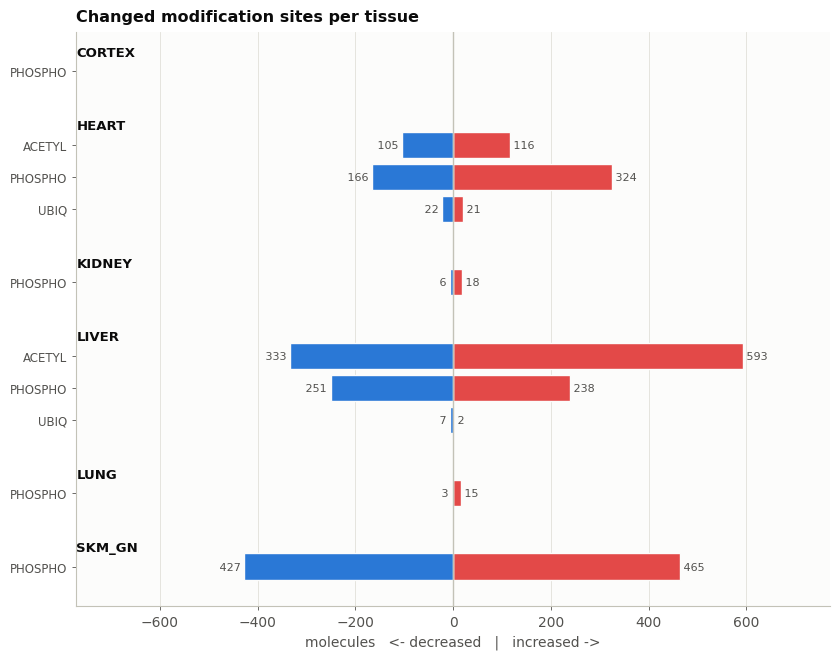

In [7]:
from transnet.visualization import plot_layer_changes

ptm_changes = pd.DataFrame([
    {"group": tissue, "layer": assay,
     "n_up": int((table.loc[table["padj"] <= 0.05, "log2FC"] > 0).sum()),
     "n_down": int((table.loc[table["padj"] <= 0.05, "log2FC"] < 0).sum())}
    for (tissue, assay), table in ptm_tables.items()
])
modification_figure = plot_layer_changes(
    ptm_changes, title="Changed modification sites per tissue")
plt.show()

## Which axis regulates each reaction

In [8]:
regulation, rows = {}, []
for tissue, graph in graphs.items():
    table = reaction_regulation_table(graph)
    regulation[tissue] = table
    regulated = table[(table["gene_axis"] != 0) | (table["metabolite_axis"] != 0)]
    rows.append({
        "tissue": tissue,
        "regulated": len(regulated),
        "enzyme only": int(((regulated["gene_axis"] != 0) & (regulated["metabolite_axis"] == 0)).sum()),
        "metabolite only": int(((regulated["gene_axis"] == 0) & (regulated["metabolite_axis"] != 0)).sum()),
        "both": int(((regulated["gene_axis"] != 0) & (regulated["metabolite_axis"] != 0)).sum()),
        "controversial": int(regulated["controversial"].sum()),
        "transcript supported": int((regulated["gene_axis_transcript_support"] == True).sum()),
    })
    (OUT / "regulation").mkdir(parents=True, exist_ok=True)
    table.to_csv(OUT / "regulation" / f"{tissue}_reaction_regulation.csv", index=False)

axes = pd.DataFrame(rows).set_index("tissue")
axes

,regulated,enzyme only,metabolite only,both,controversial,transcript supported
tissue,,,,,,
CORTEX,46,46,0,0,0,0
HEART,1237,562,488,187,75,325
KIDNEY,598,424,160,14,1,13
LIVER,1052,486,474,92,19,35
LUNG,292,290,2,0,0,0
SKM_GN,1190,519,585,86,52,143


The tissues differ in *kind*, not only in amount: heart, liver and
gastrocnemius regulate a large share of their reactions through metabolites,
while cortex and lung, whose metabolomes barely move, are enzyme-driven by
default.

## Enzyme amount against enzyme modification

The regulation table now carries a phosphorylation axis beside the gene axis.
The reactions worth separating out are the ones where the enzyme's amount held
steady while its modification state moved: an abundance-only reading calls them
unregulated.

In [9]:
phospho_rows = []
for tissue, table in regulation.items():
    if "phospho_axis" not in table:
        continue
    with_sites = table[table["n_phosphosites_changed"] > 0]
    steady = with_sites[with_sites["gene_axis"] == 0]
    phospho_rows.append({
        "tissue": tissue,
        "reactions with a changed site": len(with_sites),
        "amount steady, site moved": len(steady),
        "one direction": int((with_sites["phospho_axis"] != 0).sum()),
        "sites disagree": int(((with_sites["phospho_axis"] == 0)
                               & (with_sites["n_phosphosites_changed"] > 1)).sum()),
    })

phospho_summary = pd.DataFrame(phospho_rows)
phospho_summary.set_index("tissue")

,reactions with a changed site,"amount steady, site moved",one direction,sites disagree
tissue,,,,
CORTEX,0,0,0,0
HEART,235,114,233,2
KIDNEY,3,3,3,0
LIVER,89,53,87,2
LUNG,0,0,0,0
SKM_GN,138,69,135,3


The left block is the part a proteome alone cannot produce: reactions whose
enzyme amount held steady while its modification state moved.

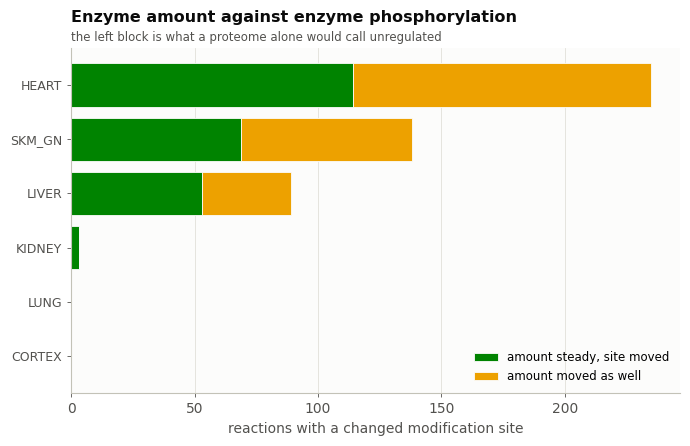

In [10]:
from transnet.visualization import plot_modification_axis

phospho_axis_figure = plot_modification_axis(
    phospho_summary.assign(
        steady=phospho_summary["amount steady, site moved"],
        also_moved=(phospho_summary["reactions with a changed site"]
                    - phospho_summary["amount steady, site moved"]),
    ).rename(columns={"tissue": "group"})[["group", "steady", "also_moved"]],
    title="Enzyme amount against enzyme phosphorylation")
plt.show()

`phospho_axis_effect` stays 0 throughout, because the edges are unsigned: the
analysis reports that these enzymes are phospho-regulated and in which
direction the sites moved, not what that does to catalysis. Signing them needs
site-level annotation the network does not have, and inventing it would put a
direction into every downstream path.

The named reactions in the focus tissue:

In [11]:
focus_table = regulation[TISSUE_FOCUS]
focus_phospho = focus_table[(focus_table["n_phosphosites_changed"] > 0)
                            & (focus_table["gene_axis"] == 0)]
focus_phospho.head(12)[["reaction", "name", "phospho_axis",
                        "n_phosphosites_changed", "metabolite_axis"]]

,reaction,name,phospho_axis,n_phosphosites_changed,metabolite_axis
101,R00124,ATP:ADP phosphatransferase; ATP + ADP <=> ADP ...,-1,1,1
114,R00139,ATP:2'-deoxy-5-hydroxymethylcytidine-5'-diphos...,-1,1,1
126,R00156,ATP:UDP phosphotransferase; ATP + UDP <=> ADP ...,-1,1,1
128,R00158,ATP:UMP phosphotransferase; ATP + UMP <=> ADP ...,-1,1,1
132,R00162,ATP:protein phosphotransferase; ATP:protein ph...,0,20,0
146,R00181,AMP aminohydrolase; AMP + H2O <=> IMP + Ammonia,-1,2,0
164,R00200,ATP:pyruvate 2-O-phosphotransferase; ATP + Pyr...,1,2,0
212,R00267,isocitrate:NADP+ oxidoreductase (decarboxylati...,1,1,1
213,R00268,oxalosuccinate carboxy-lyase (2-oxoglutarate-f...,1,1,0
267,R00330,ATP:GDP phosphotransferase; ATP + GDP <=> ADP ...,-1,1,1


## Per-pathway balance, and the metabolites doing the regulating

In [12]:
balance = regulation_axis_summary(reaction_regulation_table(graphs[TISSUE_FOCUS]))
balance.head(10)

,pathway,n_reactions,gene_activated,gene_inhibited,metabolite_activated,metabolite_inhibited,n_controversial,fraction_controversial,fraction_gene_driven,fraction_metabolite_driven
0,all,1190,318,287,365,306,52,0.043697,0.508403,0.563866


In [13]:
rows = []
for tissue, graph in graphs.items():
    result = regulatory_role_enrichment(metabolite_regulatory_roles(graph))
    counts = result["counts"]
    rows.append({
        "tissue": tissue,
        "changed metabolites": counts["n_differential"],
        "of those, regulators": counts["n_differential_regulators"],
        "background rate": round(counts["fraction_background_regulators"], 2),
        "q": round(float(result["enrichment"].set_index("role").loc["any", "q_value"]), 3),
    })
pd.DataFrame(rows).set_index("tissue")

,changed metabolites,"of those, regulators",background rate,q
tissue,,,,
CORTEX,0,0,0.60,NaN
HEART,15,8,0.64,0.889
KIDNEY,2,2,0.62,0.583
LIVER,16,8,0.62,0.908
LUNG,2,0,0.63,1.000
SKM_GN,19,13,0.66,0.752


## Signed paths, and whether the upper layers predict the metabolites

In [14]:
rows, traced_paths = [], {}
for tissue, graph in graphs.items():
    paths = trace_regulatory_paths(graph, target_layer="Metabolome", max_length=4,
                                   max_paths=20000)
    traced_paths[tissue] = paths
    verdicts, agree, tested = path_verdicts(paths)

    seeds = {n: float(d["log2fc"]) for n, d in graph.nodes(data=True)
             if d.get("layer") in ("Transcriptome", "Proteome")
             and d.get("regulated") and d.get("log2fc") is not None}
    influence = downstream_influence(graph, seeds, target_layer="Metabolome")
    measured = influence[influence["observed"].fillna(0) != 0] if "observed" in influence else influence
    predicted = int(measured["agrees"].astype("boolean").fillna(False).sum()) \
        if "agrees" in measured and not measured.empty else 0

    rows.append({"tissue": tissue, "paths": len(paths),
                 "metabolites tested": tested, "predicted by paths": agree,
                 "metabolites reached": len(measured), "predicted by propagation": predicted})
pd.DataFrame(rows).set_index("tissue")

,paths,metabolites tested,predicted by paths,metabolites reached,predicted by propagation
tissue,,,,,
CORTEX,118,0,0,0,0
HEART,0,0,0,10,6
KIDNEY,0,0,0,2,1
LIVER,0,0,0,10,5
LUNG,0,0,0,1,1
SKM_GN,0,0,0,18,15


The trained muscle's paths, with what each predicts against what was measured.
This is how a chance-level rate should be read: the misses are visible one by
one rather than hidden in a percentage.

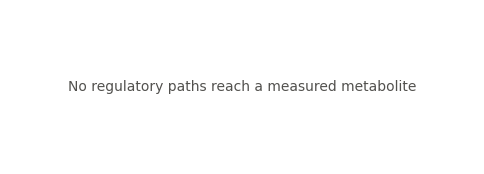

In [15]:
from transnet.visualization import plot_regulatory_paths

paths_figure = plot_regulatory_paths(traced_paths[TISSUE_FOCUS], graphs[TISSUE_FOCUS],
                                     top_n=8)
plt.show()

Neither beats chance in any tissue. Scored per path rather than per molecule
the first column would look overwhelming -- one hub metabolite reached by
dozens of overlapping paths -- which is why it is scored per molecule.

## Is each protein change transcriptional?

In [16]:
concordance = {}
rows = []
for tissue, graph in graphs.items():
    result = expression_concordance(graph)
    concordance[tissue] = result
    counts = result["counts"]
    rows.append({
        "tissue": tissue,
        "concordant": counts.get("concordant", 0),
        "protein only": counts.get("protein_only", 0),
        "against transcript": counts.get("discordant", 0),
        "beyond transcript": counts.get("protein_beyond_transcript"),
        "rho": result.get("correlation"),
    })
pd.DataFrame(rows).set_index("tissue")

,concordant,protein only,against transcript,beyond transcript,rho
tissue,,,,,
CORTEX,0,18,0,3,0.063084
HEART,36,281,7,70,0.175354
KIDNEY,1,85,1,21,0.164608
LIVER,2,390,0,62,0.182712
LUNG,0,46,0,6,0.253598
SKM_GN,30,291,6,108,0.373935


"Protein only" is partly a power artefact, since it depends on how many
transcripts passed the threshold at all. The column carrying the claim
is **beyond transcript**, a direct test of protein change minus transcript
change with standard errors, which needs no threshold. It assumes the two
platforms report fold changes on comparable scales; isobaric ratio
compression makes that conservative.

## Does ubiquitination explain the proteins that changed alone?

"Protein changed, transcript did not" is the largest class in every tissue, and
the usual explanations are translation rate and degradation. Ubiquitination is
the one of those that MoTrPAC measures, in heart and liver, so the question can
be asked rather than left open: of the proteins that moved without their
transcript, how many carry a changed ubiquitination site?

In [17]:
ubiquitin_rows = []
for tissue in MOTRPAC_PTM_ASSAYS["UBIQ"]:
    table = ptm_tables.get((tissue, "UBIQ"))
    genes = concordance.get(tissue, {}).get("table")
    if table is None or genes is None or genes.empty:
        continue

    ubiquitinated = {site_id_map.get(p, p)
                     for p in table.loc[table["padj"] <= 0.05, "protein"]}
    measured = {site_id_map.get(p, p) for p in table["protein"]}
    discordant = genes[genes["category"].isin(["protein_only", "discordant"])]
    concordant = genes[genes["category"] == "concordant"]

    def share(frame):
        proteins = set(frame["protein"].dropna()) & measured
        if not proteins:
            return None, 0
        return len(proteins & ubiquitinated) / len(proteins), len(proteins)

    discordant_share, n_discordant = share(discordant)
    concordant_share, n_concordant = share(concordant)
    ubiquitin_rows.append({
        "tissue": tissue,
        "changed ubiquitin sites": int((table["padj"] <= 0.05).sum()),
        "protein-only measured": n_discordant,
        "protein-only ubiquitinated": (None if discordant_share is None
                                       else round(discordant_share, 3)),
        "concordant measured": n_concordant,
        "concordant ubiquitinated": (None if concordant_share is None
                                     else round(concordant_share, 3)),
    })

pd.DataFrame(ubiquitin_rows).set_index("tissue") if ubiquitin_rows else "no ubiquitin data"

,changed ubiquitin sites,protein-only measured,protein-only ubiquitinated,concordant measured,concordant ubiquitinated
tissue,,,,,
HEART,43,108,0.046,18,0.056
LIVER,9,173,0.000,1,0.000


With 43 changed ubiquitin sites in heart and 9 in liver there is nothing here
to explain a class of several hundred proteins. The honest reading is that this
assay does not account for the protein-only class at eight weeks, not that
degradation is uninvolved.

## Acetylation and the mitochondrial claim

The consortium reports increased mitochondrial biogenesis in muscle, heart and
liver. Mitochondrial enzyme activity is regulated by acetylation, and heart and
liver are the two tissues where MoTrPAC measured it, so the claim can be put
against the modification rather than against abundance alone.

In [18]:
acetyl_rows = []
for tissue in MOTRPAC_PTM_ASSAYS["ACETYL"]:
    table = ptm_tables.get((tissue, "ACETYL"))
    if table is None:
        continue
    changed = table[table["padj"] <= 0.05]
    up = int((changed["log2FC"] > 0).sum())
    acetyl_rows.append({
        "tissue": tissue,
        "changed sites": len(changed),
        "up": up, "down": len(changed) - up,
        "proteins": changed["protein"].nunique(),
    })

pd.DataFrame(acetyl_rows).set_index("tissue") if acetyl_rows else "no acetyl data"

,changed sites,up,down,proteins
tissue,,,,
HEART,221,116,105,134
LIVER,926,593,333,431


## Hubs, within and across tissues

In [19]:
hub_tables = {}
for tissue, graph in graphs.items():
    hubs, without_binding, binding_share = hub_rankings(graph, top_percent=2)
    hub_tables[tissue] = hubs
    top = hubs.head(3)["name"].tolist()
    print(f"{tissue:<8}{', '.join(str(n)[:34] for n in top)}")

shared = pd.concat(
    [table.head(20).assign(tissue=tissue) for tissue, table in hub_tables.items()]
)
recurring = (shared.groupby("name")["tissue"].nunique().sort_values(ascending=False)
             .rename("tissues").to_frame().query("tissues > 1"))
recurring.head(10)

CORTEX  Peptidyl-prolyl cis-trans isomeras, Heat shock protein HSP 90-alpha (E, Heat shock 70 kDa protein 1B (Heat
HEART   ATP; Adenosine 5'-triphosphate, CoA; Coenzyme A; CoA-SH, Putrescine; 1,4-Butanediamine; 1,4
KIDNEY  Glutathione S-transferase Mu 2 (EC, Trifunctional enzyme subunit alpha, Glutathione S-transferase alpha-1 


LIVER   NADPH; TPNH; Reduced nicotinamide , NADP+; NADP; Nicotinamide adenine , NADH; DPNH; Reduced nicotinamide a
LUNG    Heat shock protein 105 kDa (Heat s, Heat shock protein HSP 90-alpha (E, Heat shock 70 kDa protein 1B (Heat
SKM_GN  CoA; Coenzyme A; CoA-SH, Arginine-hydroxylase NDUFAF5, mito, Lysophospholipid acyltransferase 5


,tissues
name,
Heat shock 70 kDa protein 1B (Heat shock 70 kDa protein 1) (HSP70-1) (HSP70.1),3
Peptidyl-prolyl cis-trans isomerase FKBP5 (PPIase FKBP5) (EC 5.2.1.8) (51 kDa FK506-binding protein) (51 kDa FKBP) (FKBP-51) (FK506-binding protein 5) (FKBP-5) (Rotamase),3
Heat shock protein HSP 90-alpha (EC 3.6.4.10) (Heat shock 86 kDa) (HSP 86) (HSP86),3
Heat shock protein 105 kDa (Heat shock 110 kDa protein),3
"Peroxisomal bifunctional enzyme (PBE) (PBFE) (Multifunctional enzyme 1) (MFE1) (Multifunctional protein 1) (MFP1) [Includes: Enoyl-CoA hydratase/3,2-trans-enoyl-CoA isomerase (EC 4.2.1.17) (EC 5.3.3.8); 3-hydroxyacyl-CoA dehydrogenase (EC 1.1.1.35)]",2
Glutathione S-transferase Mu 2 (EC 2.5.1.18) (GST 4-4) (GSTM2-2) (Glutathione S-transferase Yb-2) (GST Yb2),2
"Putrescine; 1,4-Butanediamine; 1,4-Diaminobutane; Tetramethylenediamine; Butane-1,4-diamine",2
CoA; Coenzyme A; CoA-SH,2
Stress-induced-phosphoprotein 1 (STI1) (Hsc70/Hsp90-organizing protein) (Hop),2


## Tissues compared as networks

In [20]:
jaccard = pd.DataFrame(index=tissues, columns=tissues, dtype=float)
for a in tissues:
    for b in tissues:
        if a == b:
            jaccard.loc[a, b] = 1.0
        else:
            comparison = compare_transomic_networks(
                responsive_subnetwork(graphs[a]), responsive_subnetwork(graphs[b]), a, b)
            jaccard.loc[a, b] = comparison["summary"]["edge_jaccard"]
jaccard.round(2)

,CORTEX,HEART,KIDNEY,LIVER,LUNG,SKM_GN
CORTEX,1.00,0.00,0.05,0.00,0.31,0.00
HEART,0.00,1.00,0.01,0.03,0.01,0.16
KIDNEY,0.05,0.01,1.00,0.02,0.09,0.02
LIVER,0.00,0.03,0.02,1.00,0.00,0.05
LUNG,0.31,0.01,0.09,0.00,1.00,0.00
SKM_GN,0.00,0.16,0.02,0.05,0.00,1.00


## Timing across the training weeks

Four contrasts of the same tissue against the same controls give each
molecule a trajectory over 1, 2, 4 and 8 weeks, and so a half-response time
on the network.

In [21]:
weeks = {"1w": 1.0, "2w": 2.0, "4w": 4.0, "8w": 8.0}
trajectories = {}
for label in weeks:
    for layer, table in load_motrpac_contrast(TISSUE_FOCUS, label).items():
        keyed = table.assign(node=table["feature"].map(id_map.get(layer, {})))
        # several features can map to one node (two probes, one gene); average
        # them rather than letting the last one win
        keyed = keyed.dropna(subset=["node"]).groupby("node")["log2FC"].mean()
        trajectories.setdefault(layer, {})[weeks[label]] = keyed

timing = graphs[TISSUE_FOCUS].copy()
tables = {}
for layer, series in trajectories.items():
    frame = pd.DataFrame(series)
    frame.insert(0, "feature", frame.index)
    tables[layer] = frame.reset_index(drop=True)

parameters = assign_temporal_parameters(timing, tables, id_column="feature",
                                        time_columns=list(weeks.values()))
print(f"{parameters['t_half'].notna().sum():,} molecules have a half-response time")
structure = temporal_network_structure(timing)
print(structure["degree_vs_thalf"]["interpretation"])
structure["per_layer_thalf"]

14,562 molecules have a half-response time
hubs respond later


,layer,n,median_t_half,mean_t_half
0,Transcriptome,11961,2.289467,2.907016
1,Proteome,2415,2.882188,2.997456
2,Metabolome,186,3.069479,3.189446


## The wiring, per tissue

Six responses on one interactome: the motifs each tissue uses, and the
molecules each response hangs on, are directly comparable because the
network underneath is identical.

In [22]:
from transnet import (
    convergence_significance,
    regulatory_motifs,
    structural_vulnerability,
)

rows = []
for tissue, graph in graphs.items():
    motifs = regulatory_motifs(graph, responsive_only=True)["counts"]
    convergence = convergence_significance(graph, n_randomisations=100)
    cut = structural_vulnerability(responsive_subnetwork(graph), top_n=3)
    rows.append({
        "tissue": tissue,
        "product inhibition": motifs.get("product_inhibition", 0),
        "product activation": motifs.get("product_activation", 0),
        "feed-forward": motifs.get("feed_forward", 0),
        "convergent reactions": convergence["observed"],
        "null": round(convergence["null_mean"], 1),
        "z": round(convergence["z"], 1),
        "holds it together": ", ".join(cut["name"].head(2)) if not cut.empty else "-",
    })
pd.DataFrame(rows).set_index("tissue")

,product inhibition,product activation,feed-forward,convergent reactions,null,z,holds it together
tissue,,,,,,,
CORTEX,0,0,0,0,0.0,0.0,-
HEART,2,0,0,366,14.2,10.0,"Eef2, Prkn"
KIDNEY,6,0,0,14,0.3,6.6,"Hsp90aa1, Hsph1"
LIVER,0,0,0,226,16.8,4.7,"Mrps26, Cycs"
LUNG,0,0,0,0,0.8,-0.1,Hsph1
SKM_GN,6,0,0,341,13.9,8.9,"Flnc, Mrps7"


The convergence column is the one to read against the null beside it: a
tissue with many changed molecules produces convergent reactions for free,
and the z-score says how much of it is more than that.

## Compared with the consortium's own analysis

The *Nature* paper reports genome-wide, multi-tissue patterns. The network
reading agrees with three of them and adds a mechanism the paper's
pathway-level analysis does not reach.

| MoTrPAC (Nature 2024) | Here |
|---|---|
| 58% of 8-week training-regulated features are sex-differentiated | sex is inseparable from the training response in every factor fitted below |
| 22 genes are training-regulated in all six tissues, heat shock prominent | the recurring cross-tissue hubs above |
| 67% of genes are tissue-specific | typed edge Jaccard between tissues, above |
| Increased mitochondrial biogenesis in muscle, heart and liver | checked directly below, at the level of individual reactions |

The mitochondrial claim is the one worth testing, because "mitochondrial
biogenesis" in the paper is an enrichment statement about gene sets, while
the network can say which TCA and oxidative-phosphorylation *reactions* were
regulated and through which axis.

In [23]:
TCA_ENZYMES = ["Cs", "Aco2", "Idh2", "Idh3a", "Ogdh", "Sdha", "Sdhb", "Fh", "Mdh1", "Mdh2",
               "Got1", "Got2", "Pdha1", "Dlat"]
OXPHOS = ["Ndufa1", "Ndufs1", "Sdhc", "Uqcrc1", "Uqcrc2", "Cox4i1", "Cox5a", "Atp5f1a",
          "Atp5f1b"]

rows = []
for tissue, graph in graphs.items():
    symbols = {str(d.get("symbol") or d.get("name")): n for n, d in graph.nodes(data=True)
               if d.get("layer") == "Proteome"}
    for label, panel in [("TCA cycle", TCA_ENZYMES), ("oxidative phosphorylation", OXPHOS)]:
        measured = [symbols[s] for s in panel if s in symbols
                    and graph.nodes[symbols[s]].get("log2fc") is not None]
        up = sum(1 for n in measured if (graph.nodes[n].get("regulated") or 0) > 0)
        down = sum(1 for n in measured if (graph.nodes[n].get("regulated") or 0) < 0)
        rows.append({"tissue": tissue, "panel": label, "measured": len(measured),
                     "up": up, "down": down})
mitochondrial = pd.DataFrame(rows).pivot(index="tissue", columns="panel",
                                         values=["measured", "up", "down"])
mitochondrial

measured                                  up  \
panel  TCA cycle oxidative phosphorylation TCA cycle   
tissue                                                 
CORTEX        12                         7         0   
HEART         12                         7         2   
KIDNEY        12                         7         1   
LIVER         12                         7         5   
LUNG          12                         7         0   
SKM_GN        12                         7        12   

                                      down                            
panel  oxidative phosphorylation TCA cycle oxidative phosphorylation  
tissue                                                                
CORTEX                         0         0                         0  
HEART                          0         0                         0  
KIDNEY                         0         0                         0  
LIVER                          0         0                         0  
LUNG                           0         0                         0  
SKM_GN                         5         0                         0

## Factors, read through the network

The consortium's sex result is visible here as an inability to separate
training from sex: every factor mixes them.

In [24]:
from transnet.analysis.factors import (
    matched_transcript_protein,
    pairing_robustness,
    sample_pairing_check,
    factor_cross_layer_agreement,
    factor_design_association,
    factor_network_propagation,
    factor_network_coherence,
    factor_variance_explained,
    fit_factors,
)
from transnet.datasets import load_motrpac_matrices

matrices, design = load_motrpac_matrices(TISSUE_FOCUS)
print(f"{len(design)} animals with every layer; "
      + ", ".join(f"{l} {m.shape[1]:,}" for l, m in matrices.items()))
design.groupby(["timepoint", "sex"]).size().rename("animals").to_frame()

/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/pyreadr/_pyreadr_parser.py:260: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.df['rownames'] = self.row_names


47 animals with every layer; Transcriptome 13,774, Proteome 5,152, Metabolome 1,122


animals
timepoint sex            
1w        female        5
          male          5
2w        female        5
          male          5
4w        female        5
          male          5
8w        female        5
          male          4
control   female        3
          male          5

**Are the layers the same animals?** MoTrPAC keys every sample by animal, so
they should be -- and the data can confirm it: within a group, an animal whose
transcript of a gene runs high should tend to have that protein high too.
This is also the check's own validation: a dataset paired by design has to
pass.

In [25]:
transcripts, proteins = matched_transcript_protein(
    matrices["Transcriptome"].T, matrices["Proteome"].T, graphs[TISSUE_FOCUS], id_maps=id_map)
groups = design["timepoint"].astype(str) + " " + design["sex"].astype(str)
pairing = sample_pairing_check(transcripts, proteins, groups, n_permutations=500)
print(f"{transcripts.shape[1]:,} genes in both layers; agreement as listed "
      f"{pairing['observed']:.3f}, shuffled {pairing['null_mean']:.3f} "
      f"(p = {pairing['p_value']:.3f}) -> "
      f"{'paired' if pairing['paired'] else 'pairing not confirmed'}")

1,972 genes in both layers; agreement as listed 0.030, shuffled 0.000 (p = 0.002) -> paired


In [26]:
factorisation = fit_factors(matrices, n_components=6)
association = factor_design_association(factorisation.factors_, design, ["timepoint", "sex"])
variance = factor_variance_explained(factorisation)
coherence = factor_network_coherence(
    graphs[TISSUE_FOCUS], factorisation.loadings_, id_maps=id_map, top_n=100, n_permutations=500)

summary = (association.pivot(index="factor", columns="term", values="partial_eta_squared")
           .join(variance[variance["layer"] == "all layers"].set_index("factor")["variance_accounted"])
           .join(coherence["table"].set_index("factor")[["fold_enrichment", "q_value"]]))
summary.round(3)

/Users/krv114/opt/anaconda3/envs/transnet/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


,sex,timepoint,timepoint x sex,variance_accounted,fold_enrichment,q_value
factor,,,,,,
Factor1,0.158,0.079,0.133,0.225,0.839,0.699
Factor2,0.296,0.627,0.189,0.273,1.768,0.096
Factor3,0.404,0.216,0.222,0.243,1.603,0.096
Factor4,0.446,0.593,0.458,0.221,1.126,0.426
Factor5,0.002,0.416,0.269,0.216,1.495,0.120
Factor6,0.813,0.449,0.381,0.264,1.622,0.096


A factor that follows the design but whose top features are *not* connected
on the network is co-variation without a mechanism, which is the
distinction the network exists to make, and the one a factor model alone
cannot draw.

**Every factor across the design.** Each panel is one factor's scores by
training week, split by sex (filled: female, hollow: male), headed by the
design term it follows most strongly. Read with the table above: a factor
whose sexes separate at every timepoint is a sex factor, one whose sexes
diverge only late in training is the sex-specific response MoTrPAC reports.

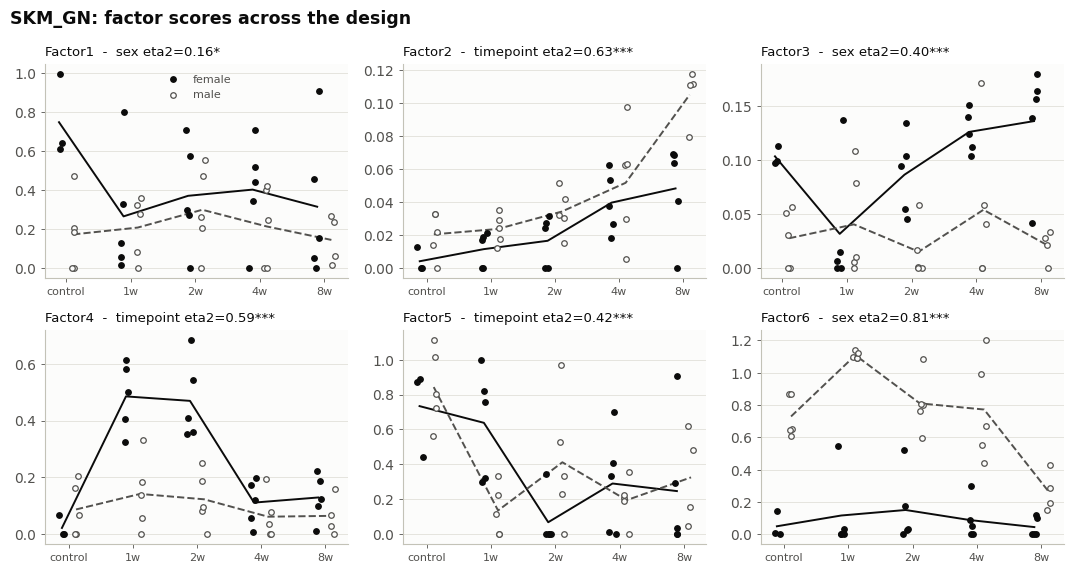

In [27]:
from transnet.visualization import (
    plot_factor_network,
    plot_factor_overview,
    plot_factor_scores,
)

FACTOR_OUT = OUT / "factors" / TISSUE_FOCUS
FACTOR_OUT.mkdir(parents=True, exist_ok=True)

scores_figure = plot_factor_scores(
    factorisation.factors_, design, x="timepoint",
    x_order=["control", "1w", "2w", "4w", "8w"], hue="sex", association=association,
    title=f"{TISSUE_FOCUS}: factor scores across the design")
scores_figure.savefig(FACTOR_OUT / "factor_scores.png", dpi=150, bbox_inches="tight")
plt.show()

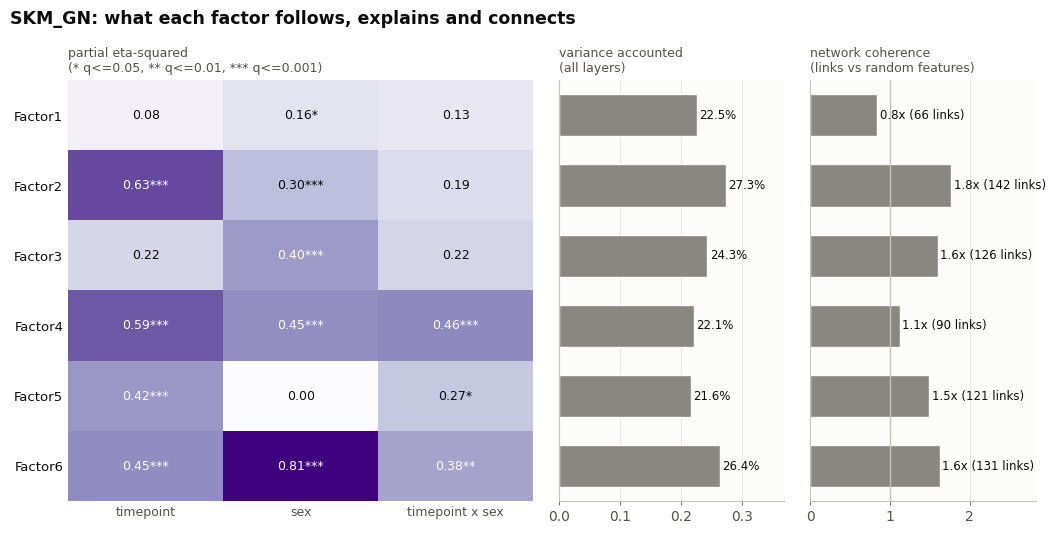

In [28]:
overview_figure = plot_factor_overview(association, variance, coherence["table"],
                                       title=f"{TISSUE_FOCUS}: what each factor follows, "
                                             f"explains and connects")
overview_figure.savefig(FACTOR_OUT / "factor_overview.png", dpi=150, bbox_inches="tight")
plt.show()

**Every factor on the network.** For each factor, the top features that the
network actually joins -- the ones behind its coherence score -- drawn in
the layered view with the reactions between them. This is where a factor
stops being a list of loadings and becomes a piece of biochemistry: which
enzymes, which of their transcripts, which metabolites of the reactions they
catalyse.

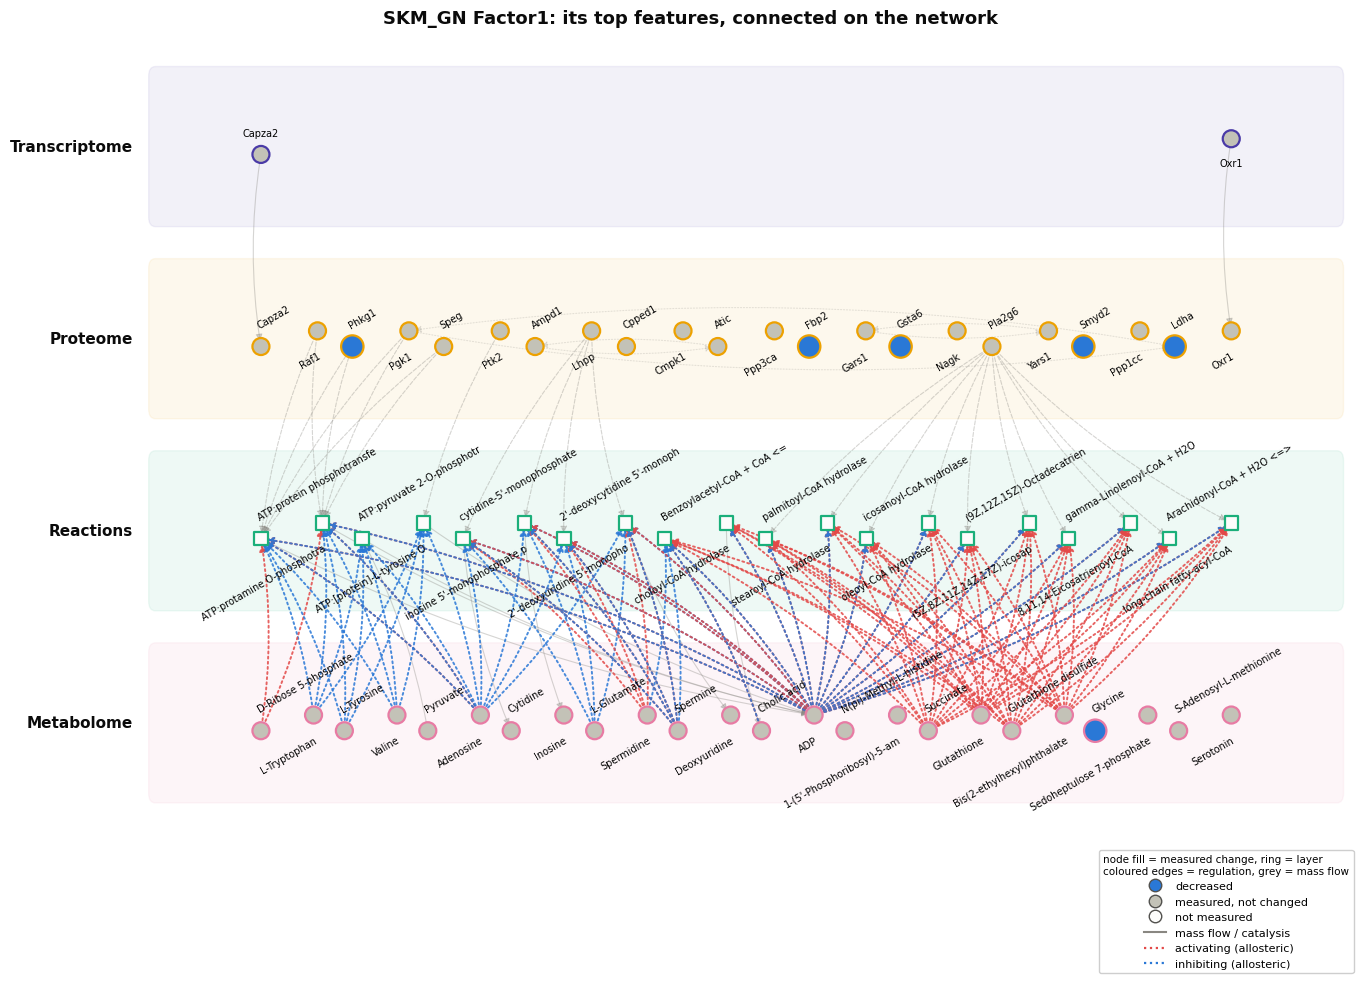

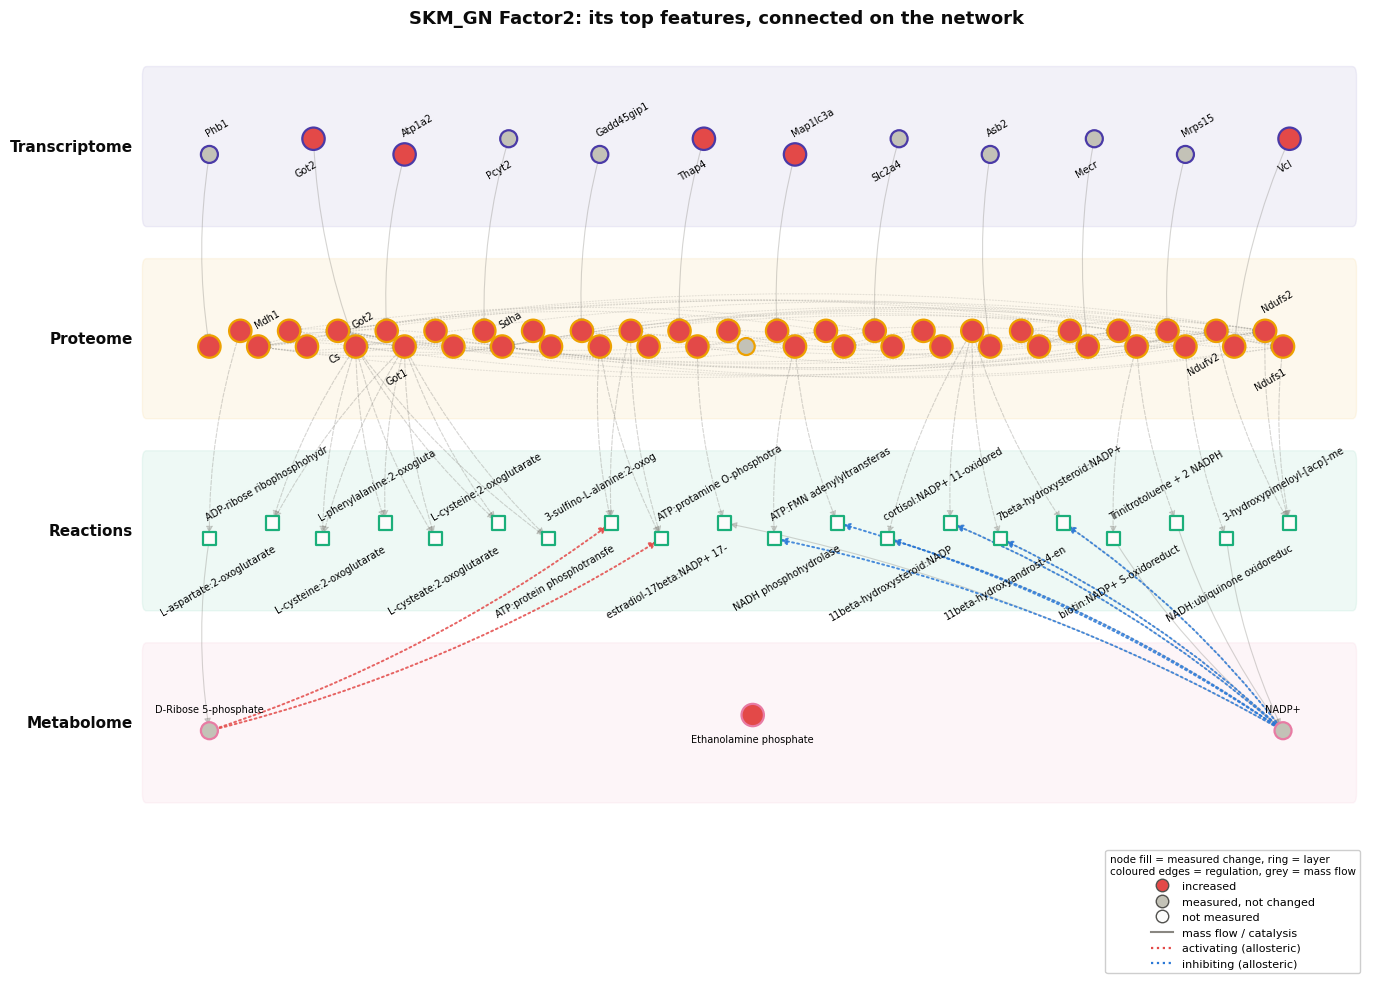

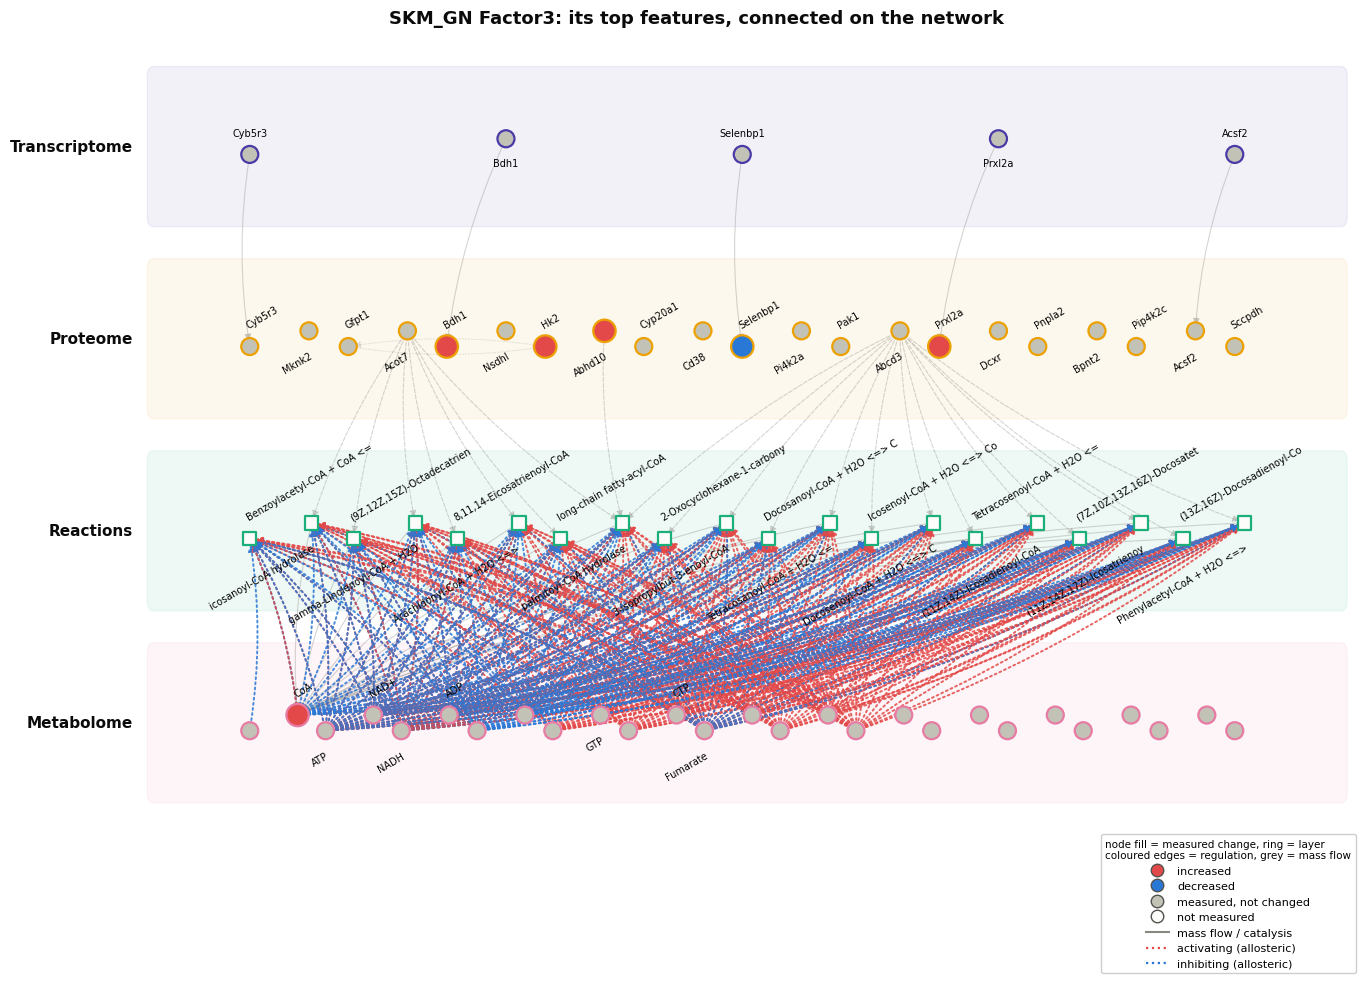

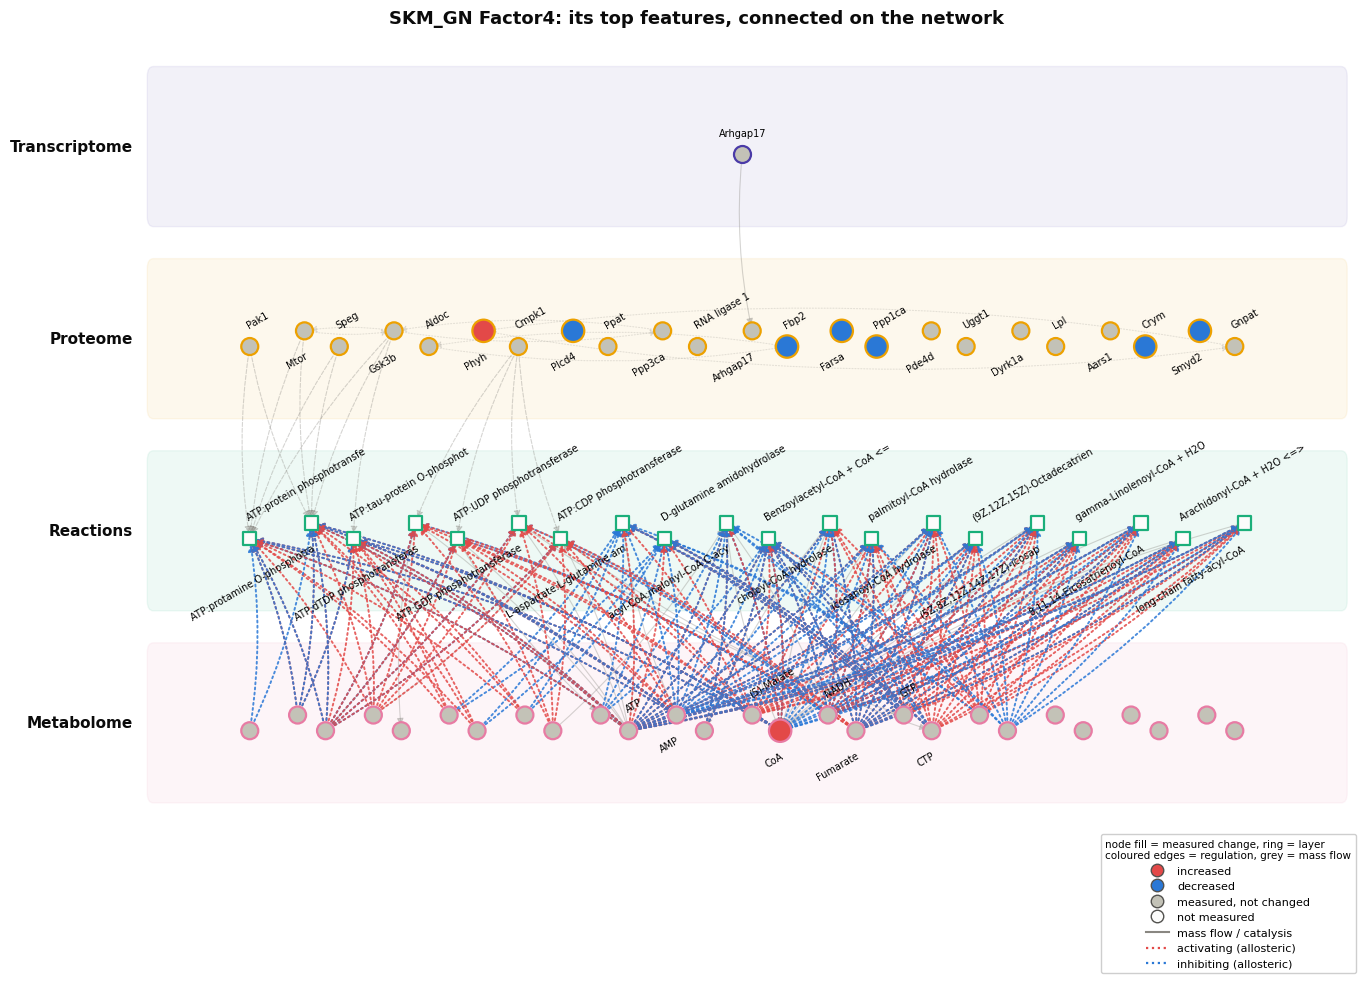

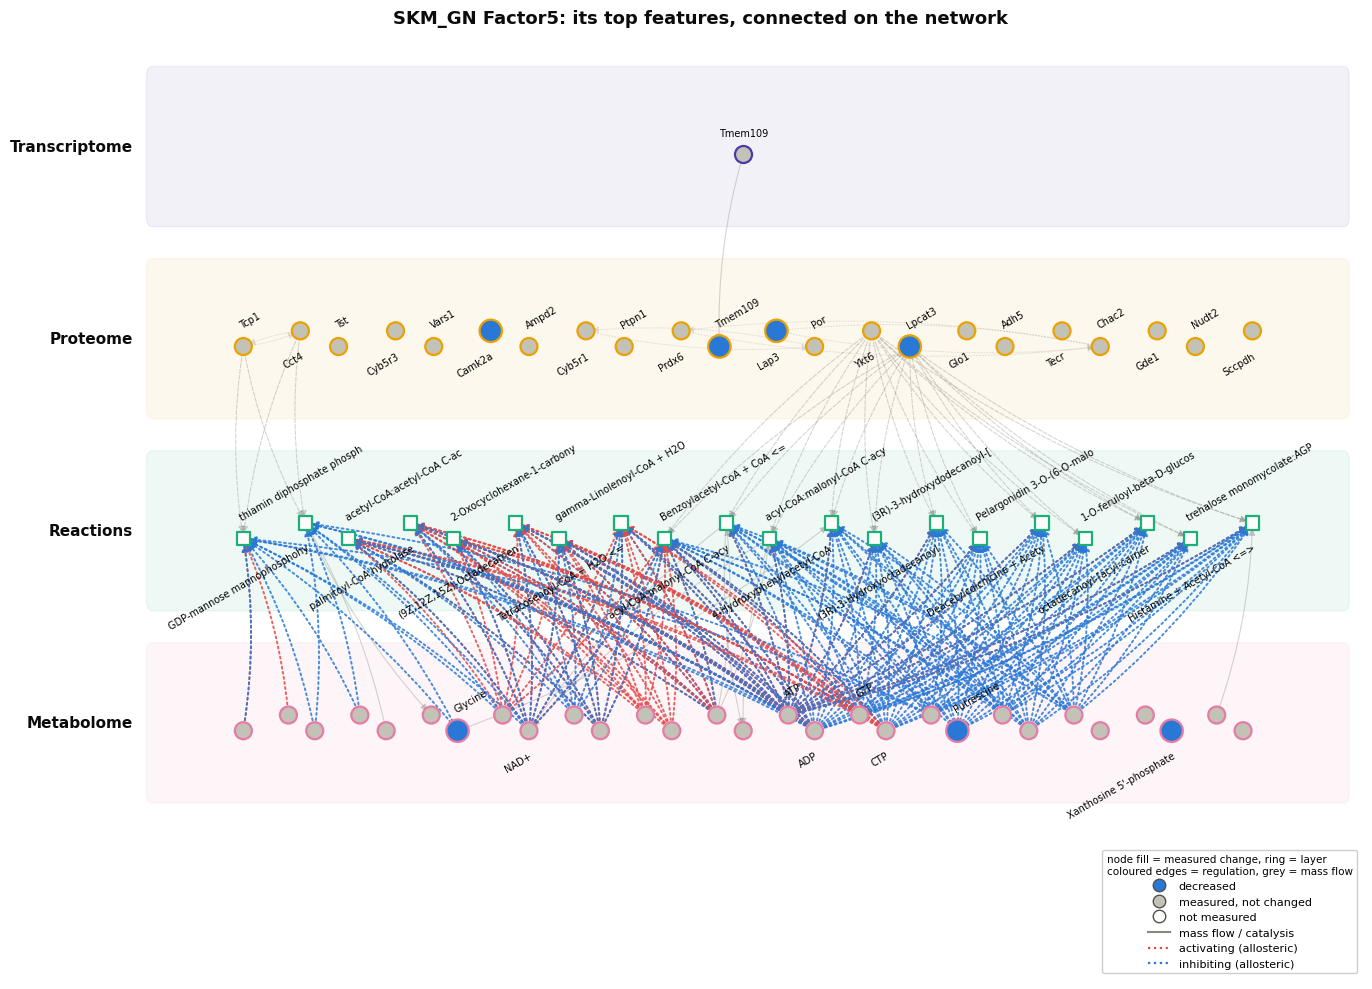

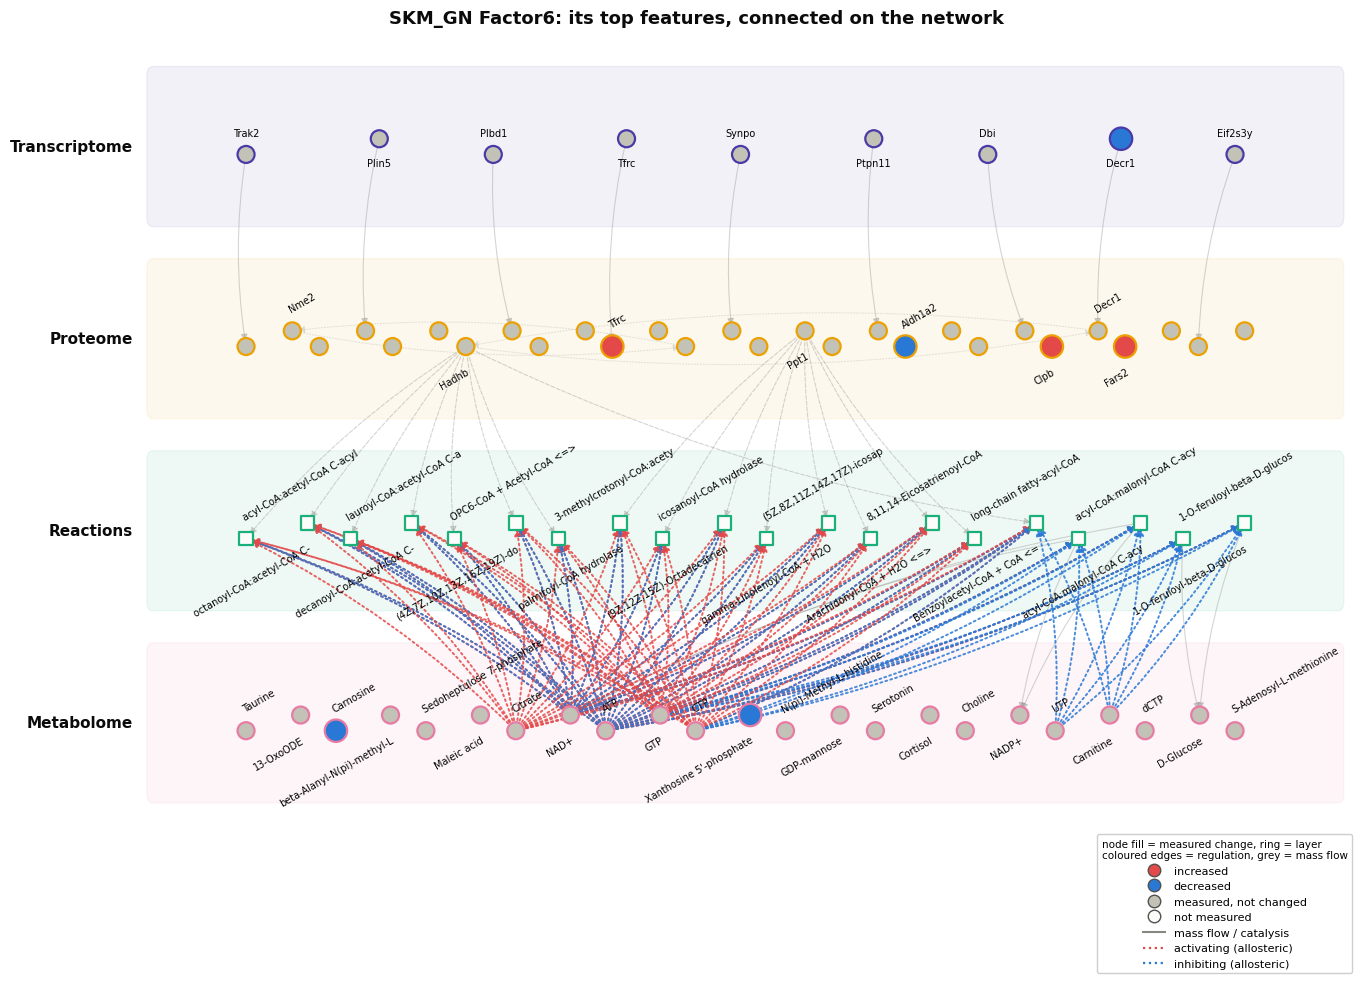

In [29]:
for factor in factorisation.factors_.columns:
    linked = coherence["nodes"].get(factor, [])
    if not linked:
        print(f"{factor}: none of its top features are joined on the network")
        continue
    figure = plot_factor_network(
        graphs[TISSUE_FOCUS], factorisation.loadings_, factor, id_maps=id_map,
        nodes=linked, max_nodes=60,
        title=f"{TISSUE_FOCUS} {factor}: its top features, connected on the network")
    figure.savefig(FACTOR_OUT / f"network_{factor}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [30]:
factorisation.factors_.to_csv(FACTOR_OUT / "scores.csv")
association.to_csv(FACTOR_OUT / "design_association.csv", index=False)
variance.to_csv(FACTOR_OUT / "variance_accounted.csv", index=False)
coherence["table"].to_csv(FACTOR_OUT / "network_coherence.csv", index=False)
for layer, frame in factorisation.loadings_.items():
    frame.to_csv(FACTOR_OUT / f"loadings_{layer.lower()}.csv")
print(f"factor tables and figures in {FACTOR_OUT}")

factor tables and figures in /Users/krv114/Documents/GitHub/transnet/data/motrpac_results/transomics/factors/SKM_GN


**Do the layers agree about each factor?** A joint factor fitted on stacked
layers can be carried by one layer alone. Projecting the animals onto a
factor within each layer and correlating those projections says which.

In [31]:
agreement = factor_cross_layer_agreement(factorisation)
agreement.pivot_table(index="factor", columns=["layer_a", "layer_b"],
                      values="correlation").round(2)

layer_a Metabolome                    Proteome
layer_b   Proteome Transcriptome Transcriptome
factor                                        
Factor1       0.53          0.30          0.50
Factor2       0.36          0.45          0.67
Factor3       0.61          0.52          0.65
Factor4       0.63          0.53          0.55
Factor5       0.44          0.24          0.63
Factor6       0.78          0.81          0.78

**Do a factor's layers land in the same place on the network?** Each layer's
strongest features are diffused separately; if the profiles overlap more than
random features of the same layers, the factor's transcripts, proteins and
metabolites are related by the biochemistry, not only by co-variation.

In [32]:
propagation = factor_network_propagation(graphs[TISSUE_FOCUS], factorisation.loadings_,
                                         id_maps=id_map, top_n=50, n_permutations=100)
propagation["table"].round(3)

,factor,seeds_Metabolome,seeds_Proteome,seeds_Transcriptome,overlap,null_overlap,p_value,q_value
0,Factor1,5,23,49,0.198,0.159,0.059,0.089
1,Factor2,5,17,44,0.173,0.139,0.149,0.149
2,Factor3,14,18,45,0.227,0.150,0.020,0.059
3,Factor4,17,24,43,0.221,0.170,0.040,0.079
4,Factor5,11,27,48,0.253,0.174,0.010,0.059
5,Factor6,10,21,50,0.194,0.158,0.149,0.149


**Which factors to trust.** Every reading in one table: the design term a
factor follows, whether the layers agree about it and whether that agreement
comes from the design (*between-group*) or from animal-to-animal variation
(*within-group* -- real here, because the animals are confirmed paired),
whether its features are directly linked, and whether its layers converge on
the network.

In [33]:
robustness = pairing_robustness(factorisation, groups, n_shuffles=200)
synthesis = (
    association.pivot(index="factor", columns="term", values="partial_eta_squared")
    .join(robustness.set_index("factor")[["agreement", "retained", "verdict"]])
    .join(coherence["table"].set_index("factor")[["fold_enrichment"]]
          .rename(columns={"fold_enrichment": "direct links vs chance"}))
    .join(propagation["table"].set_index("factor")[["overlap", "null_overlap", "q_value"]]
          .rename(columns={"q_value": "overlap q"}))
)
synthesis.round(3)

,sex,timepoint,timepoint x sex,agreement,retained,verdict,direct links vs chance,overlap,null_overlap,overlap q
factor,,,,,,,,,,
Factor1,0.158,0.079,0.133,0.444,0.541,within-group,0.839,0.198,0.159,0.089
Factor2,0.296,0.627,0.189,0.494,0.863,between-group,1.768,0.173,0.139,0.149
Factor3,0.404,0.216,0.222,0.595,0.786,within-group,1.603,0.227,0.150,0.059
Factor4,0.446,0.593,0.458,0.568,0.857,between-group,1.126,0.221,0.170,0.079
Factor5,0.002,0.416,0.269,0.435,0.615,within-group,1.495,0.253,0.174,0.059
Factor6,0.813,0.449,0.381,0.791,0.878,between-group,1.622,0.194,0.158,0.149


In [34]:
joint = synthesis["verdict"] != "single-layer"
trusted_pairing = (synthesis["verdict"] == "between-group") | pairing["paired"]
robust = synthesis[joint & trusted_pairing & (synthesis["overlap q"] <= 0.05)]
leading = (robust if not robust.empty else synthesis).sort_values(
    "overlap", ascending=False).index[0]
print(f"{leading}: where its transcripts, proteins and metabolites meet")
propagation["top_nodes"][leading].head(12)[["name", "layer", "enrichment"]]

Factor5: where its transcripts, proteins and metabolites meet


,name,layer,enrichment
P84903,Stim1,Proteome,897.970792
C01104,Trimethylamine N-oxide,Metabolome,826.358815
C00519,Hypotaurine,Metabolome,799.769010
Q5PQX1,Tor1aip1,Proteome,786.135173
Q6WN19,Rtn2,Proteome,753.723657
P28075,Psmb5,Proteome,627.914274
C17647,alpha-Muricholate,Metabolome,608.366480
94339,Mmp23,Transcriptome,539.947351
P63301,Selenow,Proteome,535.768700
R05623,"N,N,N-trimethylamine,NADPH:oxygen oxidoreductase",Reactions,535.681070


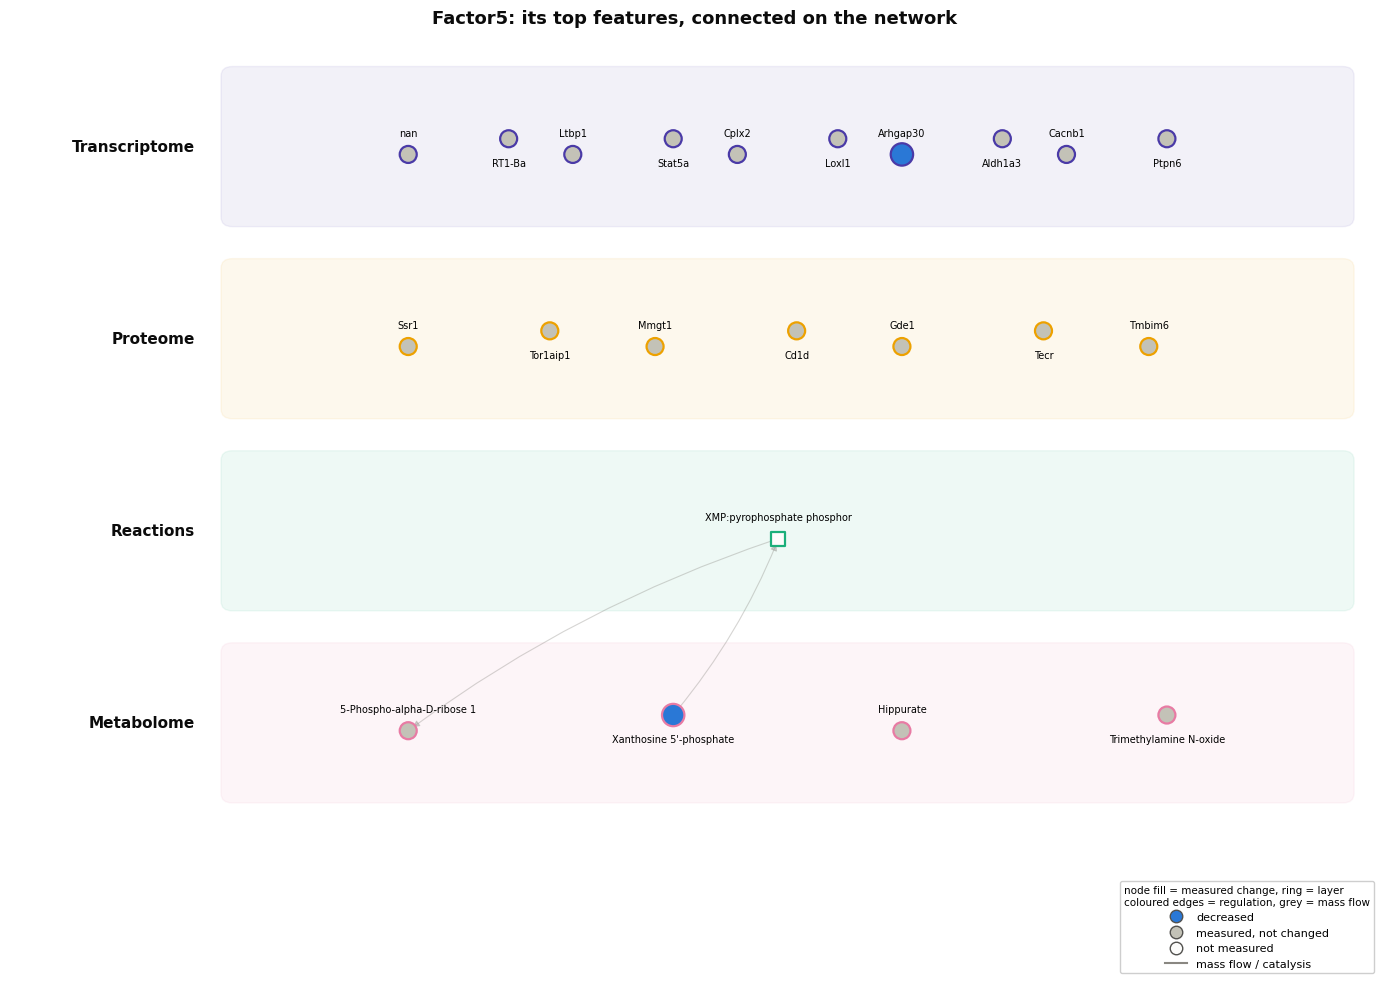

In [35]:
from transnet.visualization import plot_factor_network

plot_factor_network(graphs[TISSUE_FOCUS], factorisation.loadings_, leading,
                    id_maps=id_map, top_n=12)
plt.show()

## Figures

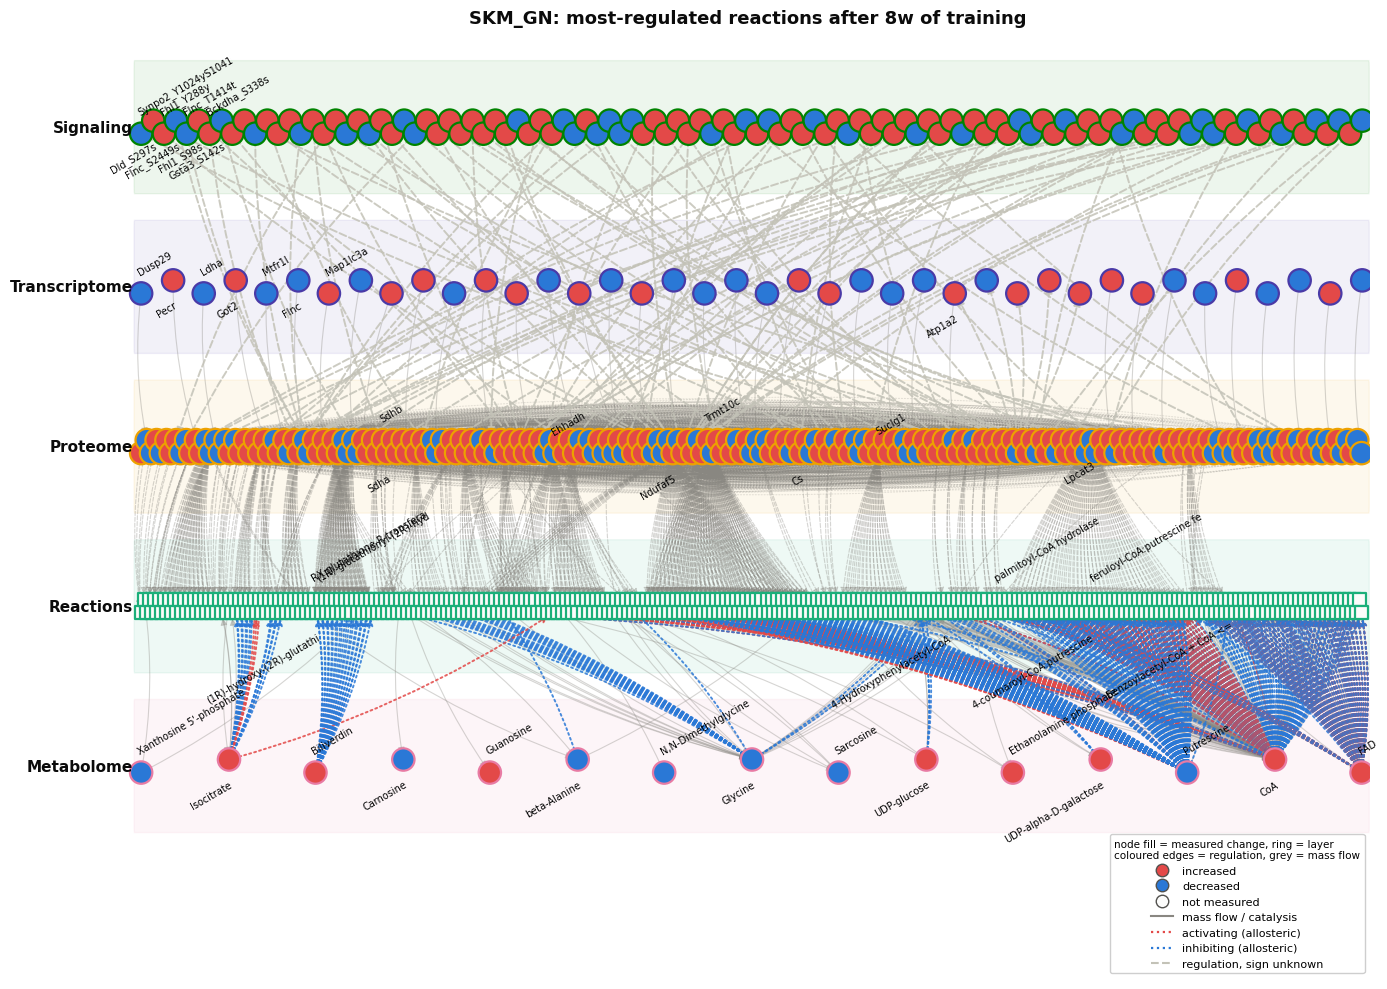

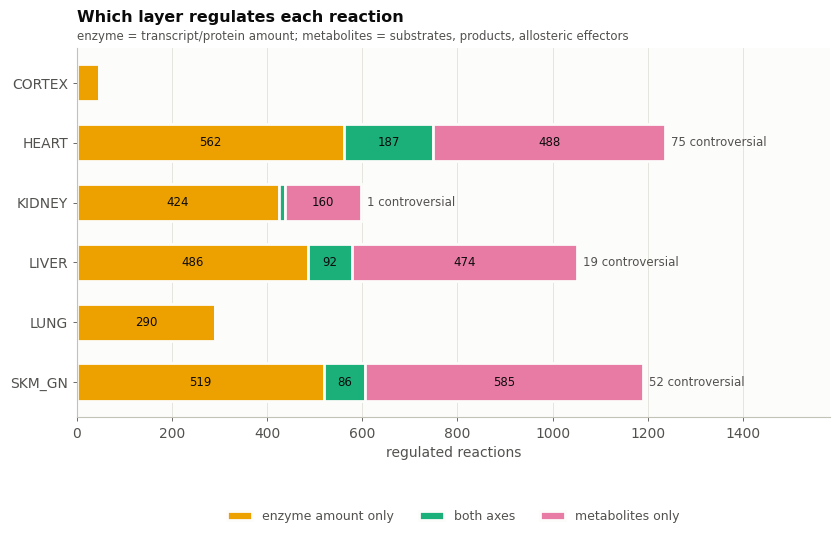

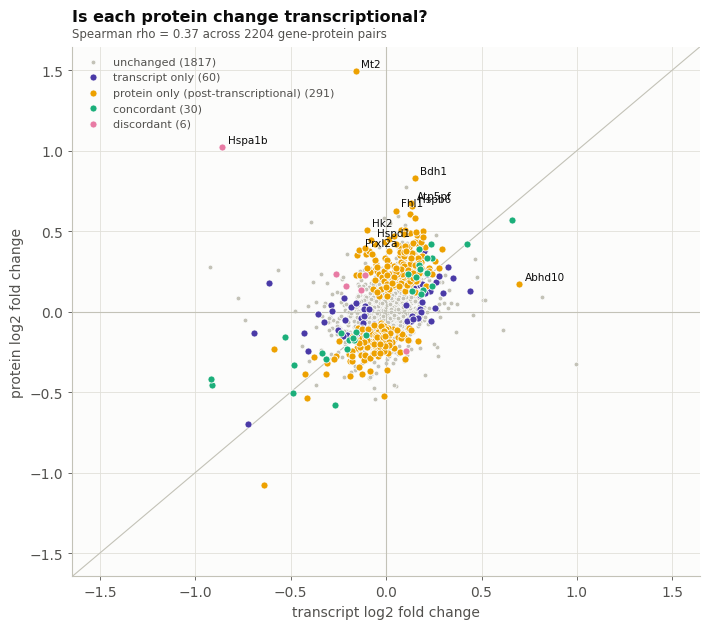

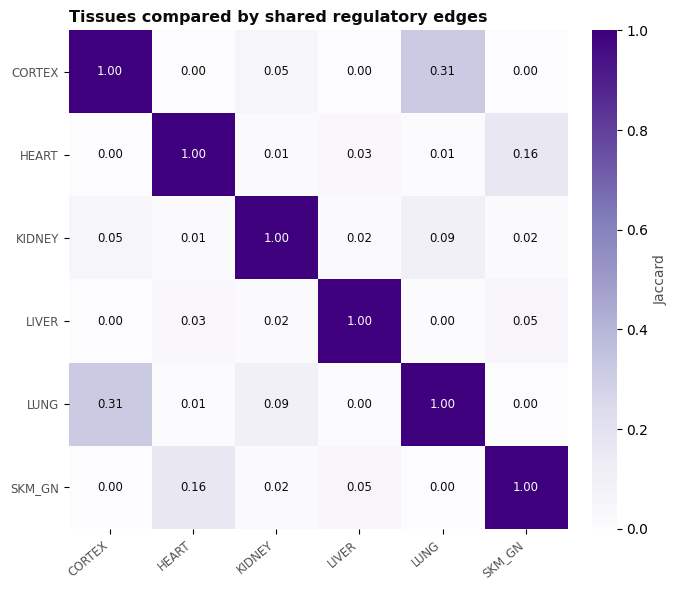

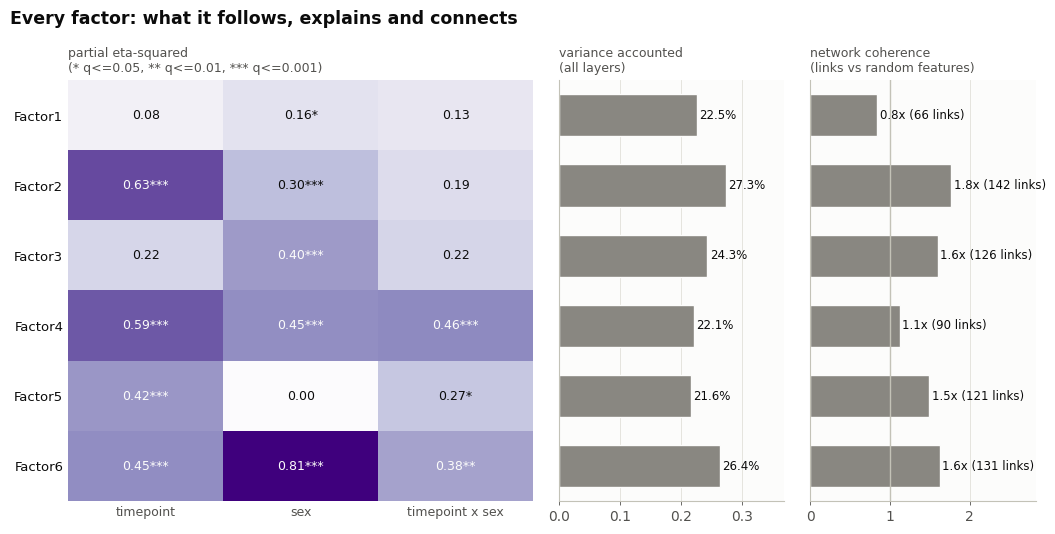

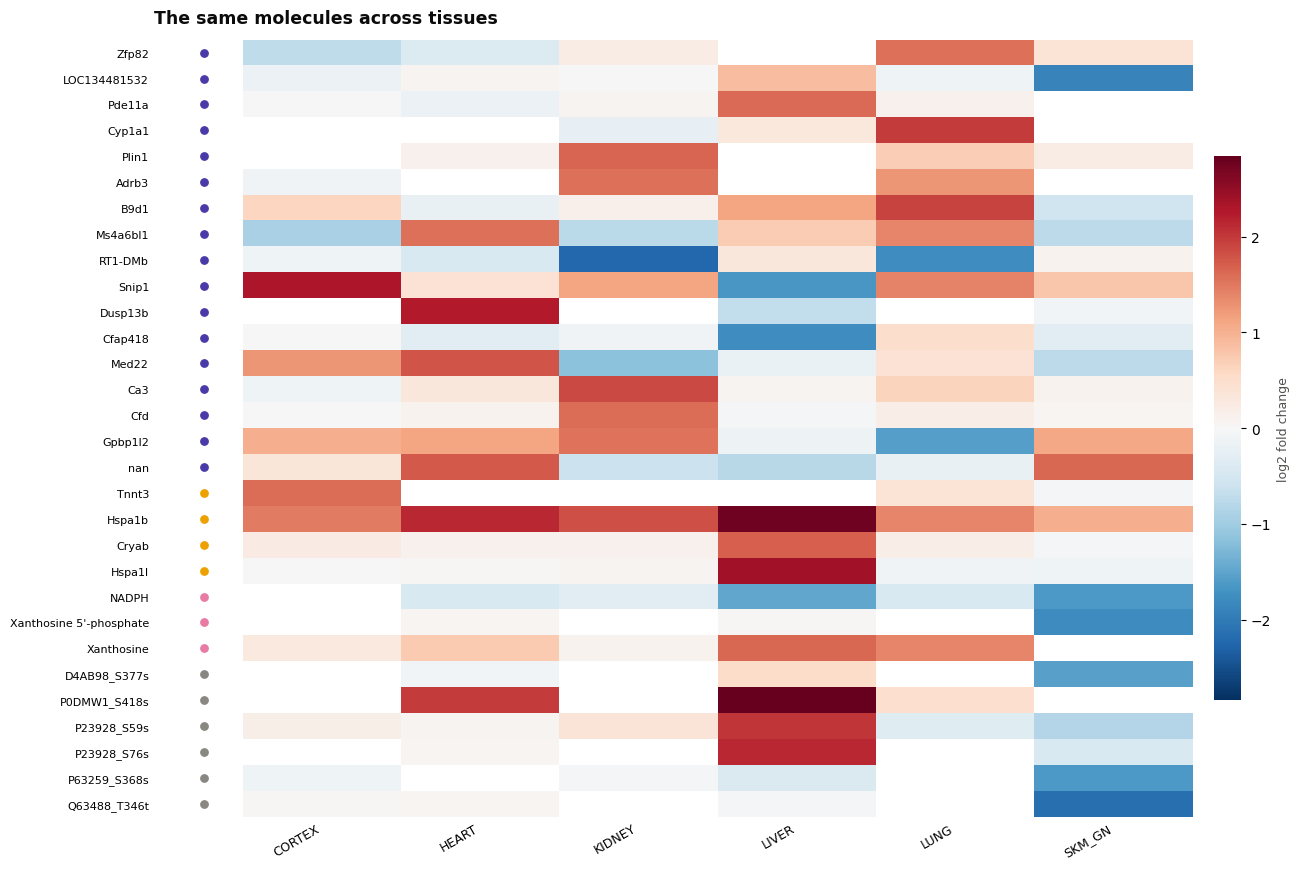

figures in /Users/krv114/Documents/GitHub/transnet/data/motrpac_results/transomics


In [36]:
from transnet.visualization import (
    plot_axis_composition,
    plot_expression_concordance,
    plot_factor_overview,
    plot_similarity_heatmap,
    plot_transomic_network,
    plot_values_heatmap,
)

FOCUS = TISSUE_FOCUS
composition = axes.reset_index().rename(columns={
    "tissue": "contrast", "enzyme only": "enzyme_axis_only",
    "metabolite only": "metabolite_axis_only", "both": "both_axes",
})

changes = pd.DataFrame({
    tissue: {n: d.get("log2fc") for n, d in graph.nodes(data=True)
             if d.get("log2fc") is not None}
    for tissue, graph in graphs.items()
})

figures = {
    f"network_{FOCUS}": plot_transomic_network(
        responsive_subnetwork(graphs[FOCUS]),
        title=f"{FOCUS}: most-regulated reactions after {TIMEPOINT} of training"),
    "axes_by_tissue": plot_axis_composition(composition, label="contrast"),
    f"concordance_{FOCUS}": plot_expression_concordance(concordance[FOCUS]),
    "modification_sites": modification_figure,
    "phospho_axis": phospho_axis_figure,
    f"paths_{FOCUS}": paths_figure,
    "edge_jaccard": plot_similarity_heatmap(
        jaccard.astype(float), title="Tissues compared by shared regulatory edges"),
    "factor_overview": plot_factor_overview(association, variance, coherence["table"]),
    "cross_tissue_changes": plot_values_heatmap(
        changes.dropna(thresh=3), graph=network, max_rows=30,
        title="The same molecules across tissues"),
}
for name, figure in figures.items():
    figure.savefig(OUT / f"{name}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"figures in {OUT}")